## Reading the data

In [1]:
import pandas as pd
from pathlib import Path
import re
import json
from sklearn.metrics import classification_report, confusion_matrix, multilabel_confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

models_names = [
    "Deepseek",
    "Falcon3",
    "Llama",
    "Mistral",
    "Phi3",
    "Qwen",
]

results_path = Path("llm_results")

def load_results(model_name: str) -> pd.DataFrame:
    file_path = results_path / f"PANDEIA_RESULTS_{model_name}_fewshot.csv"
    return pd.read_csv(file_path)

def clean_result_dataset(df):
    return df[["ID", "Subreddit", "Title", "Text", "subthemes_oneshot", "polarization_oneshot", "subthemes_zeroshot", "polarization_zeroshot", "subthemes_fewshot", "polarization_fewshot"]]

manual_labeling_dataset_path = results_path / "PANDEIA_DATASET_ManualLabeling_Final.csv"

manual_labeling_dataset = pd.read_csv(manual_labeling_dataset_path)

manual_labeling_dataset["Agreement_Polarization"] = manual_labeling_dataset["Agreement_Polarization"].fillna("Neutral") # casos de disacordo entre os rotuladores

llama_faltante = pd.read_csv(results_path / "PANDEIA_RESULTS_Llama_faltante.csv")

datasets = {}

for i in range(len(models_names)):
    datasets[models_names[i]] = load_results(models_names[i])

mask = datasets['Llama']['ID'] == llama_faltante['ID'].iloc[0]
datasets['Llama'].loc[mask, :] = llama_faltante.loc[0, datasets['Llama'].columns].values

# for model_name in models_names:
#     datasets[model_name] = clean_result_dataset(datasets[model_name])

dataset_size = datasets[models_names[0]].shape[0]

In [2]:
manual_labeling_dataset["Agreement_Subthemes"].unique()

<StringArray>
[                          'gender',                             'race',
                     'gender, race',               'disability, gender',
                             'none', 'disability, gender, lgbtq+, race',
             'gender, lgbtq+, race',                   'gender, lgbtq+',
                       'disability',                 'disability, race',
                           'lgbtq+',                     'lgbtq+, race',
       'disability, gender, lgbtq+',               'disability, lgbtq+',
         'disability, gender, race']
Length: 15, dtype: str

In [3]:
datasets['Deepseek'].head()

,ID,Date,Subreddit,Permalink,Title,Text,Author,Score,num_comment,subthemes_oneshot,polarization_oneshot,subthemes_zeroshot,polarization_zeroshot,subthemes_fewshot,polarization_fewshot
0,16iasg,2013-01-13 20:39:18 UTC,girlsgonewired,https://www.reddit.com/r/girlsgonewired/commen...,I just got back from my first CES...,I just got back from my first CES... I had hea...,Stella2010,34.0,4.0,"{\n ""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n\n ""polarization"": ""anti-DEIA"",\n ""justif...","{\n ""subtheme"": {\n ""gender"": 0,\n ""rac...","{\n ""polarization"": ""anti-DEIA"",\n ""justific...","{\n ""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n ""polarization"": ""anti-DEIA"",\n ""justific..."
1,1kyq4q,2013-08-23 20:27:25 UTC,girlsgonewired,https://www.reddit.com/r/girlsgonewired/commen...,This tech sourcer wants to make her company mo...,This tech sourcer wants to make her company mo...,SourceMonkey,5.0,7.0,"{\n\n ""subtheme"": {\n ""gender"": 1,\n ""r...","{\n ""polarization"": ""pro-DEIA"",\n ""justifica...","{\n ""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n ""polarization"": ""pro-DEIA"",\n ""justifica...","{\n ""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n ""polarization"": ""pro-DEIA"",\n ""justifica..."
2,1xji46,2014-02-10 19:17:34 UTC,girlsgonewired,https://www.reddit.com/r/girlsgonewired/commen...,What can ChallengePost do to fight sexism at h...,What can ChallengePost do to fight sexism at h...,just_here_for_pizza,17.0,3.0,"{\n\n""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n ""polarization"": ""pro-DEIA"",\n ""justifica...","{\n\n ""subtheme"": {\n ""gender"": 1,\n ""r...","{\n\n""polarization"": ""pro-DEIA"", ""justificatio...","{\n ""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n ""polarization"": ""pro-DEIA"",\n ""justifica..."
3,f3l0fd,2014-03-22 11:44:39 UTC,cscareerquestions,https://www.reddit.com/r/cscareerquestions/com...,"Is sexism in this industry overblown (or, how ...","Is sexism in this industry overblown (or, how ...",Cshsthrowaway,29.0,52.0,"{\n\n ""subtheme"": {\n ""gender"": 1,\n ""r...","{\n ""polarization"": ""anti-DEIA"",\n ""justific...","{\n\n""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n ""polarization"": ""neutral"",\n ""justificat...","{\n\n""subtheme"": {""gender"":0,""race"":0,""lgbtq+""...","{\n ""polarization"": ""neutral"",\n ""justificat..."
4,21jvbz,2014-03-28 00:03:03 UTC,girlsgonewired,https://www.reddit.com/r/girlsgonewired/commen...,I'd really like to forward some articles in th...,I'd really like to forward some articles in th...,ssjumper,4.0,4.0,"{\n\n""subtheme"": {\n ""gender"": 1,\n ""race"": ...","{\n ""polarization"": ""neutral"",\n ""justificat...","{\n ""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n ""polarization"": ""neutral"",\n ""justificat...","{\n ""subtheme"": {\n ""gender"": 0,\n ""rac...","{\n\n""polarization"": ""anti-DEIA"",\n""justificat..."


### EDA

In [4]:
manual_labeling_dataset.columns

Index(['ID', 'Date', 'Subreddit', 'Permalink', 'Title', 'Text', 'Author',
       'Score', 'num_comment', 'DEIA?_x', 'KeyWords_x', 'SubTheme_x',
       'Position_x', 'Confidence level_x', 'Justification_x', 'DEIA?_y',
       'KeyWords_y', 'SubTheme_y', 'Position_y', 'Confidence level_y',
       'Justification_y', 'IS_DEIA?', 'Agreement_Polarization',
       'Agreement_Subthemes'],
      dtype='str')

#### Subthemes distribution

In [5]:
subthemes = ["gender", "disability", "lgbtq+", "race", "none"]

parsed = (
    manual_labeling_dataset["Agreement_Subthemes"]
    .fillna("")
    .str.split(",")
    .apply(lambda x: [i.strip() for i in x])
)

for s in subthemes:
    manual_labeling_dataset[s] = parsed.apply(lambda x: s in x)

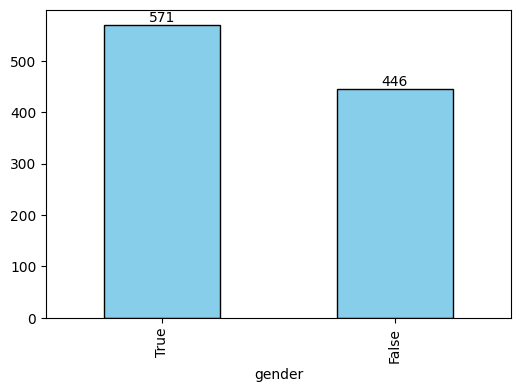

In [6]:
bar = manual_labeling_dataset.gender.value_counts().plot(kind="bar",
                                                          edgecolor="black",
                                                            color="skyblue",
                                                            figsize=(6, 4))
bar.bar_label(bar.containers[0]);

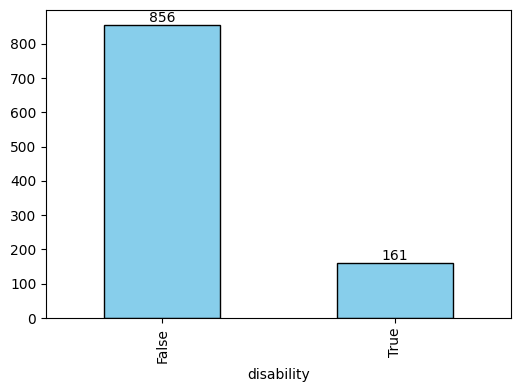

In [7]:
bar = manual_labeling_dataset.disability.value_counts().plot(kind="bar",
                                                          edgecolor="black",
                                                            color="skyblue",
                                                            figsize=(6, 4))
bar.bar_label(bar.containers[0]);

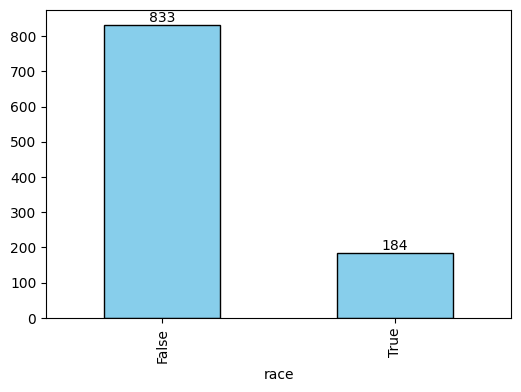

In [8]:
bar = manual_labeling_dataset.race.value_counts().plot(kind="bar",
                                                          edgecolor="black",
                                                            color="skyblue",
                                                            figsize=(6, 4))
bar.bar_label(bar.containers[0]);

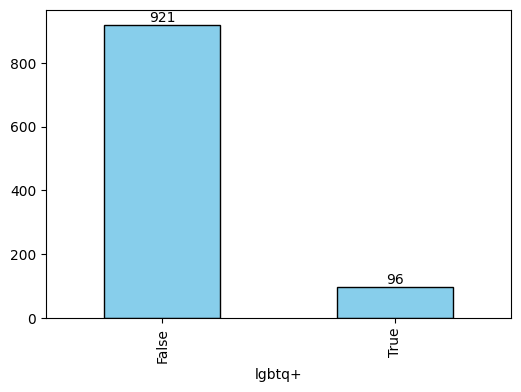

In [9]:
bar = manual_labeling_dataset['lgbtq+'].value_counts().plot(kind="bar",
                                                          edgecolor="black",
                                                            color="skyblue",
                                                            figsize=(6, 4))
bar.bar_label(bar.containers[0]);

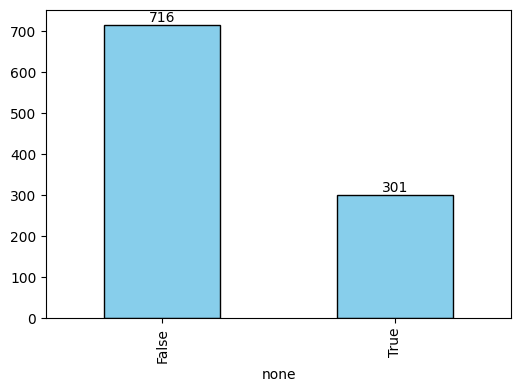

In [10]:
bar = manual_labeling_dataset.none.value_counts().plot(kind="bar",
                                                          edgecolor="black",
                                                            color="skyblue",
                                                            figsize=(6, 4))
bar.bar_label(bar.containers[0]);

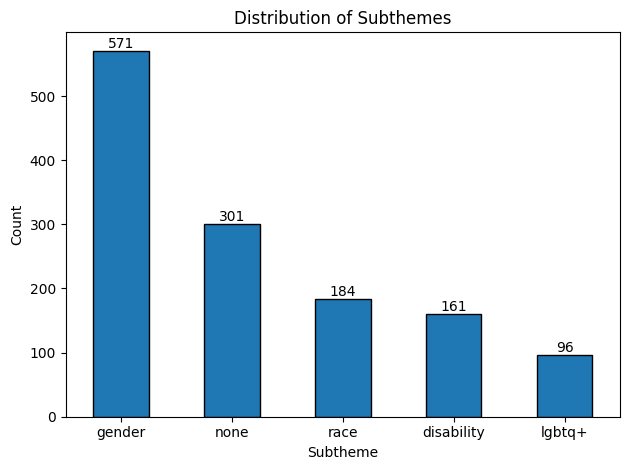

In [11]:
def plot_subthemes_distribution(df, output_path=None):

    counts = df[subthemes].sum()

    plt.figure()

    bar = counts.sort_values(ascending=False).plot(
        kind="bar",
        edgecolor="#000"
    )
    bar.bar_label(bar.containers[0])

    plt.xlabel("Subtheme")
    plt.ylabel("Count")
    plt.title("Distribution of Subthemes")
    plt.xticks(rotation=0)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300)

    plt.show()

plot_subthemes_distribution(manual_labeling_dataset)

#### Co-occurrence analysis

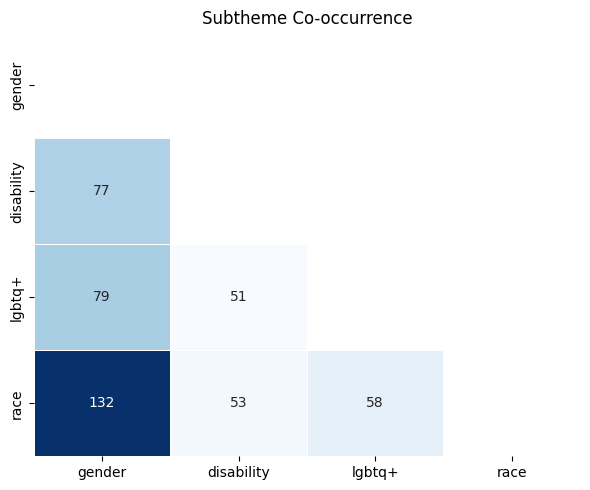

In [12]:
subthemes = ["gender", "disability", "lgbtq+", "race"]

def plot_subtheme_cooccurrence(df):

    matrix = df[subthemes].astype(int).T.dot(df[subthemes].astype(int))
    mask = np.triu(np.ones_like(matrix, dtype=bool))

    plt.figure(figsize=(6,5))

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        mask=mask,
        cbar=False,
        linewidths=.7
    )

    plt.title("Subtheme Co-occurrence")
    plt.tight_layout()
    plt.show()

plot_subtheme_cooccurrence(manual_labeling_dataset)

## Looking for problematic lines

In [13]:
SUBTHEMES = {"gender", "race", "lgbtq+", "disability", "none"}

def extract_subtheme_json(text):

    if not text or not isinstance(text, str):
        return None

    text = re.sub(r"```json|```", "", text)

    start = text.find("{")
    if start == -1:
        return None

    brace_count = 0
    json_str = None

    for i in range(start, len(text)):
        if text[i] == "{":
            brace_count += 1
        elif text[i] == "}":
            brace_count -= 1

        if brace_count == 0:
            json_str = text[start:i+1]
            break

    if json_str is None:
        return None

    try:
        return json.loads(json_str)
    except:
        return None

In [ ]:
def collect_problematic_subtheme_indices(datasets, models_names, column_name, output_dir):
    """
    For each model:
    - detects invalid JSON or invalid subtheme structure
    - saves indices of problematic rows
    - saves CSV with these indices
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    problems_by_model = {}

    for model in models_names:

        df = datasets[model]
        problematic_indices = []

        for _, row in df.iterrows():
            parsed = extract_subtheme_json(row[column_name])

            # invalid JSON
            if parsed is None:
                problematic_indices.append(row["ID"])
                continue

            subtheme = parsed.get("subtheme")

            # subtheme field missing or not a dict
            if not isinstance(subtheme, dict):
                problematic_indices.append(row["ID"])
                continue

            # verify if all expected subthemes are present
            if not SUBTHEMES.issubset(set(subtheme.keys())):
                problematic_indices.append(row["ID"])
                continue

        problems_by_model[model] = problematic_indices

        pd.DataFrame({
            "row_index": problematic_indices
        }).to_csv(
            output_dir / f"{model}_subtheme_problematic_rows.csv",
            index=False
        )

    return problems_by_model

In [15]:
subtheme_problem_idx_zeroshot = collect_problematic_subtheme_indices(
    datasets,
    models_names,
    "subthemes_zeroshot",
    "results/json_problems/subtheme_json_problems_zeroshot"
)

subtheme_problem_idx_oneshot = collect_problematic_subtheme_indices(
    datasets,
    models_names,
    "subthemes_oneshot",
    "results/json_problems/subtheme_json_problems_oneshot"
)

subtheme_problem_idx_fewshot = collect_problematic_subtheme_indices(
    datasets,
    models_names,
    "subthemes_fewshot",
    "results/json_problems/subtheme_json_problems_fewshot"
)

In [16]:
subtheme_problem_idx_zeroshot

{'Deepseek': [],
 'Falcon3': [],
 'Llama': [],
 'Mistral': [],
 'Phi3': [],
 'Qwen': []}

In [17]:
subtheme_problem_idx_oneshot

{'Deepseek': [],
 'Falcon3': ['wgc8s6'],
 'Llama': ['dn1icd'],
 'Mistral': [],
 'Phi3': [],
 'Qwen': []}

In [18]:
subtheme_problem_idx_fewshot

{'Deepseek': [],
 'Falcon3': [],
 'Llama': ['dn1icd'],
 'Mistral': [],
 'Phi3': [],
 'Qwen': []}

In [19]:
manual_labeling_dataset[manual_labeling_dataset['ID'].isin(['dn1icd', '1jru54x', 'wgc8s6'])]

,ID,Date,Subreddit,Permalink,Title,Text,Author,Score,num_comment,DEIA?_x,...,Confidence level_y,Justification_y,IS_DEIA?,Agreement_Polarization,Agreement_Subthemes,gender,disability,lgbtq+,race,none
126,dn1icd,2019-10-25 18:22:25 UTC,technology,https://www.reddit.com/r/technology/comments/d...,I researched technologies for protection of fo...,I researched technologies for protection of fo...,prototyperspective,43,11,no,...,5.0,The text centers on environmental technologies...,no,Pro-DEIA,lgbtq+,False,False,True,False,False
279,wgc8s6,2022-08-04 21:05:49 UTC,ExperiencedDevs,https://www.reddit.com/r/ExperiencedDevs/comme...,"Code is a Craft, not a Competition-- and why i...","Code is a Craft, not a Competition-- and why i...",Zihas990,345,61,no,...,5.0,The text is a philosophical and organizational...,no,Neutral,none,False,False,False,False,True
744,1jru54x,2025-04-05 03:17:34 UTC,womenintech,https://www.reddit.com/r/womenintech/comments/...,Angry and Bitter over pretty bad sexism as fem...,Angry and Bitter over pretty bad sexism as fem...,SnooCupcakes780,21,4,yes,...,4.0,She delivered exceptional results in a global ...,yes,Pro-DEIA,gender,True,False,False,False,False


In [20]:
datasets['Falcon3'][datasets['Falcon3']['ID'].isin(subtheme_problem_idx_oneshot['Falcon3'])]['subthemes_zeroshot'].iloc[0]

'{"subtheme": { "gender": 0, "race": 0, "lgbtq+": 0, "disability": 0, "none": 0 }, "justification": "The message excerpt discusses concepts related to coding as a craft and its implications. It touches on wisdom, flow state, and the practical aspects of creating code that works. Given these themes, the appropriate subthemes are gender, race, lgbtq+, disability, and none. All other subthemes are marked as 0 since they do not directly relate to any of the discussed subthemes."}'

In [21]:
datasets['Llama'][datasets['Llama']['ID'].isin(subtheme_problem_idx_oneshot['Llama'])]['subthemes_zeroshot'].iloc[0]

'{"subtheme": {"gender": 2, "race": 2, "lgbtq+": 1, "disability": 1, "none": 3}, "justification": "][*] 0.00"}'

In [22]:
datasets['Deepseek'].subthemes_oneshot.iloc[0]

'{\n  "subtheme": {\n    "gender": 1,\n    "race": 0,\n    "lgbtq+": 0,\n    "disability": 0,\n    "none": 0\n  },\n  "justification": "The message discusses how women were negatively portrayed and objectified at CES, which relates to gender dynamics."\n}'

### LLMs Evaluation

In [23]:
def extract_subthemes_from_json(text):

    parsed = extract_subtheme_json(text)

    if parsed is None:
        return None

    subtheme_dict = parsed.get("subtheme")

    if not isinstance(subtheme_dict, dict):
        return None

    vector = []

    for label in SUBTHEMES:

        value = subtheme_dict.get(label, 0)

        if value in [1, "1", True]:
            vector.append(1)
        else:
            vector.append(0)

    return vector

def parse_true_subthemes(text):

    if pd.isna(text):
        return [0]*len(SUBTHEMES)

    labels = [x.strip() for x in text.split(",")]

    vector = []

    for label in SUBTHEMES:
        if label in labels:
            vector.append(1)
        else:
            vector.append(0)

    return vector

In [24]:
def extract_subtheme_predictions(df, column_name):
    vectors = []
    problematic_indices = []

    for idx, row in df.iterrows():

        vec = extract_subthemes_from_json(row[column_name])

        if vec is None:
            problematic_indices.append(idx)
            vec = [0]*len(SUBTHEMES)

        vectors.append(vec)

    return vectors, problematic_indices

In [25]:
def build_multilabel_arrays(y_true_series, y_pred_vectors):

    y_true = np.array(
        [parse_true_subthemes(x) for x in y_true_series]
    )

    y_pred = np.array(y_pred_vectors)

    return y_true, y_pred

In [26]:
from sklearn.metrics import classification_report, multilabel_confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


def evaluate_multilabel(y_true, y_pred, output_dir):

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # -----------------------------
    # Classification report
    # -----------------------------
    report = classification_report(
        y_true,
        y_pred,
        target_names=SUBTHEMES,
        zero_division=0,
        output_dict=True
    )

    report_df = pd.DataFrame(report).transpose()

    report_df.to_csv(
        output_dir / "multilabel_classification_report.csv"
    )

    # -----------------------------
    # Multilabel confusion matrices
    # -----------------------------
    mcm = multilabel_confusion_matrix(y_true, y_pred)

    for i, label in enumerate(SUBTHEMES):

        cm = mcm[i]

        cm_df = pd.DataFrame(
            cm,
            index=["True 0", "True 1"],
            columns=["Pred 0", "Pred 1"]
        )

        # salvar CSV
        cm_df.to_csv(
            output_dir / f"confusion_matrix_{label}.csv"
        )

        # heatmap
        plt.figure(figsize=(4,4))

        sns.heatmap(
            cm_df,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False
        )

        plt.title(f"Confusion Matrix - {label}")
        plt.ylabel("True label")
        plt.xlabel("Predicted label")

        plt.tight_layout()

        plt.savefig(
            output_dir / f"confusion_matrix_{label}.png",
            dpi=300
        )

        plt.close()

    return report_df, mcm

In [27]:
deia_indexes = manual_labeling_dataset[manual_labeling_dataset['IS_DEIA?'] == 'yes'].index

In [28]:
y_polarization = manual_labeling_dataset.loc[deia_indexes, "Agreement_Polarization"].to_numpy()
y_subthemes = manual_labeling_dataset.loc[deia_indexes, "Agreement_Subthemes"].to_numpy()

In [29]:
def plot_subthemes_distribution(df, title, output_path=None):

    counts = df[subthemes].sum()

    plt.figure()

    bar = counts.sort_values(ascending=False).plot(
        kind="bar",
        edgecolor="#000"
    )

    bar.bar_label(bar.containers[0])

    plt.xlabel("Subtheme")
    plt.ylabel("Count")
    plt.title(title)
    plt.xticks(rotation=0)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300)

    plt.close()

In [30]:
def plot_subtheme_cooccurrence(df, title, output_path=None):

    matrix = df[subthemes].astype(int).T.dot(df[subthemes].astype(int))

    mask = np.triu(np.ones_like(matrix, dtype=bool))

    plt.figure(figsize=(6,5))

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        mask=mask,
        cbar=False,
        linewidths=.7
    )

    plt.title(title)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300)

    plt.close()

In [31]:
for model_name in models_names:
    pred_vectors, problem_idx = extract_subtheme_predictions(
        datasets[model_name].loc[deia_indexes],
        "subthemes_zeroshot"
    )

    y_true, y_pred = build_multilabel_arrays(
        manual_labeling_dataset.loc[deia_indexes, "Agreement_Subthemes"],
        pred_vectors
    )

    report_df, mcm = evaluate_multilabel(y_true, y_pred, Path("results") / "subthemes" / "zeroshot" / f"{model_name}_evaluation")


for model_name in models_names:
    pred_vectors, problem_idx = extract_subtheme_predictions(
        datasets[model_name].loc[deia_indexes],
        "subthemes_oneshot"
    )

    y_true, y_pred = build_multilabel_arrays(
        manual_labeling_dataset.loc[deia_indexes, "Agreement_Subthemes"],
        pred_vectors
    )

    report_df, mcm = evaluate_multilabel(y_true, y_pred, Path("results") / "subthemes" / "oneshot" / f"{model_name}_evaluation")

for model_name in models_names:
    pred_vectors, problem_idx = extract_subtheme_predictions(
        datasets[model_name].loc[deia_indexes],
        "subthemes_fewshot"
    )

    y_true, y_pred = build_multilabel_arrays(
        manual_labeling_dataset.loc[deia_indexes, "Agreement_Subthemes"],
        pred_vectors
    )

    report_df, mcm = evaluate_multilabel(y_true, y_pred, Path("results") / "subthemes" / "fewshot" / f"{model_name}_evaluation")

In [32]:
SUBTHEMES = ["gender", "race", "lgbtq+", "disability", "none"]

def extract_subthemes_columns(df, column_name):

    def parse_row(text):

        data = extract_subtheme_json(text)

        if not data or "subtheme" not in data:
            return {s: 0 for s in SUBTHEMES}

        sub_dict = data["subtheme"]

        return {
            s: int(sub_dict.get(s, 0))
            for s in SUBTHEMES
        }

    parsed = df[column_name].apply(parse_row)

    subtheme_df = pd.DataFrame(list(parsed), index=df.index)

    for s in SUBTHEMES:
        df[s] = subtheme_df[s]

    return df

In [33]:
for model_name in models_names:

    datasets[model_name] = extract_subthemes_columns(
        datasets[model_name],
        "subthemes_zeroshot"
    )

    datasets[model_name] = extract_subthemes_columns(
        datasets[model_name],
        "subthemes_oneshot"
    )

    datasets[model_name] = extract_subthemes_columns(
        datasets[model_name],
        "subthemes_fewshot"
    )

In [34]:
def plot_subthemes_distribution(df, title, output_path=None):

    counts = df[subthemes].sum()

    plt.figure()

    bar = counts.sort_values(ascending=False).plot(
        kind="bar",
        edgecolor="#000"
    )

    bar.bar_label(bar.containers[0])

    plt.xlabel("Subtheme")
    plt.ylabel("Count")
    plt.title(title)
    plt.xticks(rotation=0)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300)

    plt.close()

def plot_subtheme_cooccurrence(df, title, output_path=None):

    matrix = df[subthemes].astype(int).T.dot(df[subthemes].astype(int))

    mask = np.triu(np.ones_like(matrix, dtype=bool))

    plt.figure(figsize=(6,5))

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        mask=mask,
        cbar=False,
        linewidths=.7
    )

    plt.title(title)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300)

    plt.close()

In [35]:
for model_name in models_names:

    df_sub = datasets[model_name].loc[deia_indexes]

    output_dir = Path("results") / "subthemes" / "zeroshot" / f"{model_name}_evaluation"
    output_dir.mkdir(parents=True, exist_ok=True)

    title = f"{model_name} — Zeroshot"

    plot_subthemes_distribution(
        df_sub,
        title,
        output_dir / "subthemes_distribution.png"
    )

    plot_subtheme_cooccurrence(
        df_sub,
        title,
        output_dir / "subthemes_cooccurrence.png"
    )

In [36]:
for model_name in models_names:

    df_sub = datasets[model_name].loc[deia_indexes]

    output_dir = Path("results") / "subthemes" / "oneshot" / f"{model_name}_evaluation"
    output_dir.mkdir(parents=True, exist_ok=True)

    title = f"{model_name} — Oneshot"

    plot_subthemes_distribution(
        df_sub,
        title,
        output_dir / "subthemes_distribution.png"
    )

    plot_subtheme_cooccurrence(
        df_sub,
        title,
        output_dir / "subthemes_cooccurrence.png"
    )

In [37]:
for model_name in models_names:

    df_sub = datasets[model_name].loc[deia_indexes]

    output_dir = Path("results") / "subthemes" / "fewshot" / f"{model_name}_evaluation"
    output_dir.mkdir(parents=True, exist_ok=True)

    title = f"{model_name} — Fewshot"

    plot_subthemes_distribution(
        df_sub,
        title,
        output_dir / "subthemes_distribution.png"
    )

    plot_subtheme_cooccurrence(
        df_sub,
        title,
        output_dir / "subthemes_cooccurrence.png"
    )